# Custom Lattice Workflow


**Purpose.** Build and inspect a user-defined tight-binding graph with custom coordinates, complex bonds, onsite terms, and registry integration.


**Lattice model.** The custom Hamiltonian is $H=\sum_i \epsilon_i|i\rangle\langle i|+\sum_{(i,j)}(t_{ij}|i\rangle\langle j|+t_{ij}^*|j\rangle\langle i|)$ on a six-site ring with an additional complex chord.


**Variables.** $i$ and $j$ label lattice sites; $\epsilon_i$ are onsite energies passed as `onsite`; $t_{ij}$ are bond matrix elements stored in `bonds`; `positions` gives plotting coordinates; `hopping` is the default bond value when a bond omits its own matrix element.


**Outputs.** The notebook checks dense/sparse agreement and Hermiticity, prints the ground energy, plots graph connectivity, matrix phase, and a ground-state lattice profile.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models import Lattice, TightBindingModel
from quantum_lattice_models.plotting import (
    plot_hamiltonian_matrix,
    plot_lattice_graph,
    plot_lattice_state,
)
from quantum_lattice_models.registry import get_model_info, register_model, unregister_model
from quantum_lattice_models.spectra import eigensystem

In [2]:
angles = np.linspace(0.0, 2.0 * np.pi, 6, endpoint=False)
positions = np.column_stack([np.cos(angles), np.sin(angles)])
bonds = [(index, (index + 1) % 6) for index in range(6)]
bonds.append((0, 3, 0.35j))
lattice = Lattice(
    positions=positions,
    bonds=bonds,
    metadata={"description": "six-site ring with a complex chord"},
)
model = TightBindingModel(lattice)
H = model.hamiltonian(hopping=1.0, onsite=[0.2, 0.0, -0.2, 0.2, 0.0, -0.2])
H_sparse = model.sparse_hamiltonian(
    hopping=1.0,
    onsite=[0.2, 0.0, -0.2, 0.2, 0.0, -0.2],
)
values, vectors = eigensystem(H)

print("Custom lattice summary")
print(f"  shape: {H.shape}")
print(f"  dense/sparse agree: {np.allclose(H, H_sparse.toarray())}")
print(f"  Hermitian: {np.allclose(H, H.conj().T)}")
print(f"  ground energy: {values[0]:.6f}")

Custom lattice summary
  shape: (6, 6)
  dense/sparse agree: True
  Hermitian: True
  ground energy: -2.032287


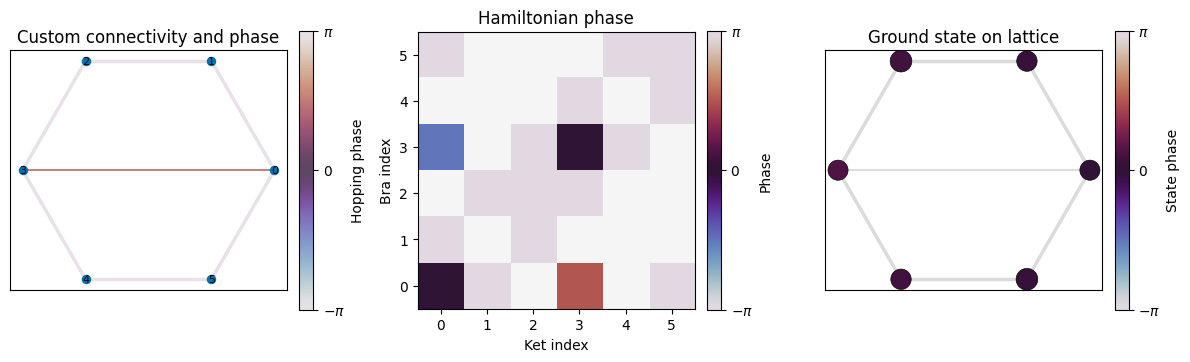

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
plot_lattice_graph(H, ax=axes[0], show_colorbar=True, labels=True, arrows=True)
axes[0].set_title("Custom connectivity and phase")
plot_hamiltonian_matrix(H, ax=axes[1], mode="phase")
plot_lattice_state(H, vectors[:, 0], ax=axes[2])
axes[2].set_title("Ground state on lattice")
fig.tight_layout()

In [4]:
def six_site_ring(hopping: float = 1.0):
    return TightBindingModel(lattice).hamiltonian(hopping=hopping)


register_model(
    "six_site_ring_demo",
    category="user",
    basis="single particle",
    dimension="6",
    return_type="LatticeHamiltonian",
    description="Notebook-defined six-site ring",
    builder=six_site_ring,
    defaults={"hopping": 1.0},
)
try:
    info = get_model_info("six_site_ring_demo")
    print("Temporary registry entry")
    print(f"  category: {info.category}")
    print(f"  dimension: {info.dimension}")
    print(f"  default shape: {info.builder(**info.defaults).shape}")
finally:
    unregister_model("six_site_ring_demo")

Temporary registry entry
  category: user
  dimension: 6
  default shape: (6, 6)
